In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, log_loss
from sklearn.calibration import CalibratedClassifierCV
from pathlib import Path
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [2]:
# ------------------------------------------------------------
# Always run from project root (so paths like data/... work)
# ------------------------------------------------------------

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(PROJECT_ROOT)

print("Working directory:", Path.cwd())


Working directory: /Users/darellsam/Documents/Programming/AI + Machine Learning/SuperBowl LX Predictions


In [3]:
# ------------------------------------------------------------
# Load cached datasets (fast, local)
# ------------------------------------------------------------

# ------------------------------------------------------------
# nflverse core caches
# ------------------------------------------------------------
PBP_PATH   = Path("data/raw/nflverse/pbp_1999_2025.parquet")
SCHED_PATH = Path("data/raw/nflverse/schedules_1999_2025.parquet")

# ------------------------------------------------------------
# nflverse roster & availability caches (Dataset 5)
# ------------------------------------------------------------
SEASON_ROSTERS_PATH = Path("data/raw/nflverse/season_rosters_1999_2025.parquet")
WEEKLY_ROSTERS_PATH = Path("data/raw/nflverse/weekly_rosters_1999_2025.parquet")
DEPTH_CHARTS_PATH  = Path("data/raw/nflverse/depth_charts_2001_2025.parquet")

# ------------------------------------------------------------
# Elo cache (Kaggle / FiveThirtyEight mirror)
# ------------------------------------------------------------
ELO_PATH = Path("data/raw/elo/nfl_games.parquet")

# ------------------------------------------------------------
# Betting odds cache (SpreadSpoke)
# ------------------------------------------------------------
ODDS_PATH = Path("data/raw/odds/odds.parquet")
ODDS_TEAMS_CSV = Path("data/raw/odds/nfl_teams.csv")  # optional helper table

# ------------------------------------------------------------
# Verify all required cached files exist
# ------------------------------------------------------------
required_paths = [
    PBP_PATH,
    SCHED_PATH,
    SEASON_ROSTERS_PATH,
    WEEKLY_ROSTERS_PATH,
    DEPTH_CHARTS_PATH,
    ELO_PATH,
    ODDS_PATH,
]

missing = [p for p in required_paths if not p.exists()]
if missing:
    raise FileNotFoundError(
        "Missing cached files (run 00_data_setup.ipynb first):\n"
        + "\n".join(f"- {p}" for p in missing)
    )

# ------------------------------------------------------------
# Load datasets
# ------------------------------------------------------------
pbp            = pd.read_parquet(PBP_PATH)
schedules      = pd.read_parquet(SCHED_PATH)
season_rosters = pd.read_parquet(SEASON_ROSTERS_PATH)
weekly_rosters = pd.read_parquet(WEEKLY_ROSTERS_PATH)
depth_charts   = pd.read_parquet(DEPTH_CHARTS_PATH)
elo            = pd.read_parquet(ELO_PATH)
odds           = pd.read_parquet(ODDS_PATH)

# Optional mapping table (used for joins / name normalization)
odds_teams = pd.read_csv(ODDS_TEAMS_CSV) if ODDS_TEAMS_CSV.exists() else None

# ------------------------------------------------------------
# Sanity check output
# ------------------------------------------------------------
print(f"PBP loaded:            {pbp.shape[0]:,} rows | {pbp.shape[1]} cols")
print(f"Schedules loaded:      {schedules.shape[0]:,} rows | {schedules.shape[1]} cols")
print(f"Season rosters loaded: {season_rosters.shape[0]:,} rows | {season_rosters.shape[1]} cols")
print(f"Weekly rosters loaded: {weekly_rosters.shape[0]:,} rows | {weekly_rosters.shape[1]} cols")
print(f"Depth charts loaded:   {depth_charts.shape[0]:,} rows | {depth_charts.shape[1]} cols")
print(f"Elo loaded:            {elo.shape[0]:,} rows | {elo.shape[1]} cols")
print(f"Odds loaded:           {odds.shape[0]:,} rows | {odds.shape[1]} cols")
print(f"Odds teams loaded:     {'yes' if odds_teams is not None else 'no'}")


PBP loaded:            1,279,435 rows | 398 cols
Schedules loaded:      7,276 rows | 46 cols
Season rosters loaded: 66,457 rows | 37 cols
Weekly rosters loaded: 906,213 rows | 37 cols
Depth charts loaded:   1,294,829 rows | 26 cols
Elo loaded:            15,740 rows | 12 cols
Odds loaded:           14,358 rows | 17 cols
Odds teams loaded:     yes


In [4]:
# ------------------------------------------------------------
# Step 1: Game table + targets (schedules is already game-level)
# ------------------------------------------------------------

games = schedules.copy()

# Ensure datetime
games["game_date"] = pd.to_datetime(games["gameday"])

# Targets
games["home_win"] = (games["home_score"] > games["away_score"]).astype(int)
games["point_diff"] = games["home_score"] - games["away_score"]

# Quick sanity view
games[["season","week","game_date","home_team","away_team","home_score","away_score","home_win"]].head()


,season,week,game_date,home_team,away_team,home_score,away_score,home_win
0,1999,1,1999-09-12,ATL,MIN,14.0,17.0,0
1,1999,1,1999-09-12,CHI,KC,20.0,17.0,1
2,1999,1,1999-09-12,CLE,PIT,0.0,43.0,0
3,1999,1,1999-09-12,GB,OAK,28.0,24.0,1
4,1999,1,1999-09-12,IND,BUF,31.0,14.0,1


In [5]:
# ------------------------------------------------------------
# Step 2: Merge SpreadSpoke odds (works with either schema)
# ------------------------------------------------------------

# 1) Ensure we have a joinable date
games["game_date"] = pd.to_datetime(games["gameday"])

# SpreadSpoke usually stores the date in schedule_date
if "schedule_date" in odds.columns:
    odds["game_date"] = pd.to_datetime(odds["schedule_date"])
elif "game_date" in odds.columns:
    odds["game_date"] = pd.to_datetime(odds["game_date"])
else:
    raise KeyError("Odds data has no schedule_date or game_date column.")

# 2) Standardize team columns
if "home_team" not in odds.columns and "team_home" in odds.columns:
    odds = odds.rename(columns={"team_home": "home_team"})
if "away_team" not in odds.columns and "team_away" in odds.columns:
    odds = odds.rename(columns={"team_away": "away_team"})

if "home_team" not in odds.columns or "away_team" not in odds.columns:
    raise KeyError(
        f"Odds is missing team columns. Found columns: {list(odds.columns)}"
    )

# 3) Standardize spread + total
# If spread_line/total_line don't exist, derive them from common SpreadSpoke names
if "spread_line" not in odds.columns:
    if "spread_favorite" in odds.columns:
        odds["spread_line"] = pd.to_numeric(odds["spread_favorite"], errors="coerce")
    else:
        odds["spread_line"] = pd.NA

if "total_line" not in odds.columns:
    if "over_under_line" in odds.columns:
        odds["total_line"] = pd.to_numeric(odds["over_under_line"], errors="coerce")
    else:
        odds["total_line"] = pd.NA

# 4) Keep only columns that actually exist (avoid KeyError)
odds_cols_wanted = [
    "game_date",
    "home_team",
    "away_team",
    "spread_line",
    "total_line",
    "stadium_neutral",
    "weather_temperature",
    "weather_wind_mph",
    "weather_humidity",
]
odds_cols_present = [c for c in odds_cols_wanted if c in odds.columns]

odds_keep = odds[odds_cols_present].copy()

# 5) Merge odds into games
games = games.merge(
    odds_keep,
    on=["game_date", "home_team", "away_team"],
    how="left",
    suffixes=("", "_odds")
)

# 6) If schedules already has spread_line/total_line, fill only where missing
if "spread_line_odds" in games.columns:
    games["spread_line"] = games["spread_line"].fillna(games["spread_line_odds"])
    games.drop(columns=["spread_line_odds"], inplace=True)

if "total_line_odds" in games.columns:
    games["total_line"] = games["total_line"].fillna(games["total_line_odds"])
    games.drop(columns=["total_line_odds"], inplace=True)

# Quick sanity check
games[["home_team","away_team","spread_line","total_line"]].head()


,home_team,away_team,spread_line,total_line
0,ATL,MIN,-4.0,49.0
1,CHI,KC,-3.0,38.0
2,CLE,PIT,-6.0,37.0
3,GB,OAK,9.0,43.0
4,IND,BUF,-3.0,45.5


In [6]:
# ------------------------------------------------------------
# Step 3: Merge Elo ratings + build Elo diff features
# ------------------------------------------------------------

elo2 = elo.copy()
elo2["game_date"] = pd.to_datetime(elo2["date"])

elo2 = elo2.rename(columns={
    "team1": "home_team",
    "team2": "away_team",
    "elo1": "home_elo",
    "elo2": "away_elo",
})

games = games.merge(
    elo2[["game_date","home_team","away_team","home_elo","away_elo","elo_prob1"]],
    on=["game_date","home_team","away_team"],
    how="left"
)

games["elo_diff"] = games["home_elo"] - games["away_elo"]

games[["home_team","away_team","home_elo","away_elo","elo_diff","elo_prob1"]].head()


,home_team,away_team,home_elo,away_elo,elo_diff,elo_prob1
0,ATL,MIN,1623.158,1658.901,-35.743,0.542005
1,CHI,KC,1410.448,1515.063,-104.615,0.443235
2,CLE,PIT,1300.000,1490.527,-190.527,0.326823
3,GB,OAK,1599.394,1453.127,146.267,0.771385
4,IND,BUF,1376.095,1523.618,-147.523,0.383424


In [7]:
# ------------------------------------------------------------
# Step 4: Build rolling "recent form" per team from game outcomes
# ------------------------------------------------------------

N_GAMES = 5  # tweak later

# Home perspective
home_results = games[["season","week","game_date","home_team","home_win","point_diff"]].rename(columns={
    "home_team": "team",
    "home_win": "win",
})
home_results["team_point_diff"] = home_results["point_diff"]

# Away perspective
away_results = games[["season","week","game_date","away_team","home_win","point_diff"]].rename(columns={
    "away_team": "team",
})
away_results["win"] = 1 - away_results["home_win"]
away_results["team_point_diff"] = -away_results["point_diff"]
away_results = away_results.drop(columns=["home_win"])

team_games = pd.concat([home_results, away_results], ignore_index=True)
team_games = team_games.sort_values(["team","game_date","season","week"])

# Rolling features
team_games["recent_win_rate"] = (
    team_games.groupby("team")["win"]
    .rolling(N_GAMES, min_periods=1).mean()
    .reset_index(level=0, drop=True)
)

team_games["recent_point_diff"] = (
    team_games.groupby("team")["team_point_diff"]
    .rolling(N_GAMES, min_periods=1).mean()
    .reset_index(level=0, drop=True)
)

team_games[["team","game_date","win","recent_win_rate","recent_point_diff"]].head()

,team,game_date,win,recent_win_rate,recent_point_diff
7284,ARI,1999-09-12,1,1.000000,1.000000
7298,ARI,1999-09-19,0,0.500000,-1.000000
43,ARI,1999-09-27,0,0.333333,-5.333333
7324,ARI,1999-10-03,0,0.250000,-11.000000
58,ARI,1999-10-10,1,0.400000,-6.600000


In [8]:
# ------------------------------------------------------------
# Step 5: Attach rolling team form to each game
# ------------------------------------------------------------

games = games.merge(
    team_games[["team","game_date","recent_win_rate","recent_point_diff"]],
    left_on=["home_team","game_date"],
    right_on=["team","game_date"],
    how="left"
).rename(columns={
    "recent_win_rate": "home_recent_win_rate",
    "recent_point_diff": "home_recent_point_diff"
}).drop(columns=["team"])

games = games.merge(
    team_games[["team","game_date","recent_win_rate","recent_point_diff"]],
    left_on=["away_team","game_date"],
    right_on=["team","game_date"],
    how="left"
).rename(columns={
    "recent_win_rate": "away_recent_win_rate",
    "recent_point_diff": "away_recent_point_diff"
}).drop(columns=["team"])

games[["home_team","away_team","home_recent_win_rate","away_recent_win_rate"]].head()

,home_team,away_team,home_recent_win_rate,away_recent_win_rate
0,ATL,MIN,0.0,1.0
1,CHI,KC,1.0,0.0
2,CLE,PIT,0.0,1.0
3,GB,OAK,1.0,0.0
4,IND,BUF,1.0,0.0


In [9]:
# ------------------------------------------------------------
# Step 6A: QB continuity (from schedules' qb ids)
# ------------------------------------------------------------

games = games.sort_values(["season","week","game_date"])

# For each team, track QB id over time (home and away combined)
home_qb = games[["season","week","game_date","home_team","home_qb_id"]].rename(columns={
    "home_team":"team", "home_qb_id":"qb_id"
})
away_qb = games[["season","week","game_date","away_team","away_qb_id"]].rename(columns={
    "away_team":"team", "away_qb_id":"qb_id"
})
team_qb = pd.concat([home_qb, away_qb], ignore_index=True).sort_values(["team","game_date","season","week"])

# consecutive same-QB streak length
team_qb["qb_changed"] = team_qb.groupby("team")["qb_id"].apply(lambda s: s != s.shift(1))
team_qb["qb_streak"] = team_qb.groupby("team")["qb_changed"].cumsum()
team_qb["qb_streak_len"] = team_qb.groupby(["team","qb_streak"]).cumcount() + 1

# attach to games
games = games.merge(
    team_qb[["team","game_date","qb_streak_len"]],
    left_on=["home_team","game_date"],
    right_on=["team","game_date"],
    how="left"
).rename(columns={"qb_streak_len":"home_qb_streak"}).drop(columns=["team"])

games = games.merge(
    team_qb[["team","game_date","qb_streak_len"]],
    left_on=["away_team","game_date"],
    right_on=["team","game_date"],
    how="left"
).rename(columns={"qb_streak_len":"away_qb_streak"}).drop(columns=["team"])

games[["home_team","away_team","home_qb_streak","away_qb_streak"]].head()


/var/folders/yc/5rwhttcd67gfbl6z5x95zvdc0000gp/T/ipykernel_52110/2751814188.py:17: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)
  team_qb["qb_changed"] = team_qb.groupby("team")["qb_id"].apply(lambda s: s != s.shift(1))


,home_team,away_team,home_qb_streak,away_qb_streak
0,ATL,MIN,1,1
1,CHI,KC,1,1
2,CLE,PIT,1,1
3,GB,OAK,1,1
4,IND,BUF,1,1


In [10]:
# ------------------------------------------------------------
# Step 6B: Depth chart starter proxy (how many rank-1 players listed)
# ------------------------------------------------------------

dc = depth_charts.copy()

# Standardize to match schedules: team column exists and uses abbreviations
# We'll count starters as pos_rank == 1
if "pos_rank" in dc.columns:
    starters = dc[dc["pos_rank"] == 1].copy()
else:
    starters = dc.copy()  # fallback if pos_rank missing (shouldn't happen)

starter_counts = (
    starters.groupby(["season","week","team","game_type"])["player_name"]
    .nunique()
    .reset_index(name="starter_count")
)

# Merge starter counts onto games for REG season + playoffs by game_type
games = games.merge(
    starter_counts[["season","week","team","game_type","starter_count"]],
    left_on=["season","week","home_team","game_type"],
    right_on=["season","week","team","game_type"],
    how="left"
).rename(columns={"starter_count":"home_starter_count"}).drop(columns=["team"])

games = games.merge(
    starter_counts[["season","week","team","game_type","starter_count"]],
    left_on=["season","week","away_team","game_type"],
    right_on=["season","week","team","game_type"],
    how="left"
).rename(columns={"starter_count":"away_starter_count"}).drop(columns=["team"])

games["starter_count_diff"] = games["home_starter_count"] - games["away_starter_count"]

games[["home_team","away_team","home_starter_count","away_starter_count","starter_count_diff"]].head()


,home_team,away_team,home_starter_count,away_starter_count,starter_count_diff
0,ATL,MIN,NaN,NaN,NaN
1,CHI,KC,NaN,NaN,NaN
2,CLE,PIT,NaN,NaN,NaN
3,GB,OAK,NaN,NaN,NaN
4,IND,BUF,NaN,NaN,NaN


In [11]:
# ------------------------------------------------------------
# Step 7: Build modeling dataset (X + y)
# ------------------------------------------------------------

feature_cols = [
    # betting market (very strong signal)
    "spread_line", "total_line", "home_moneyline", "away_moneyline",

    # Elo (optional; will be missing after 2016 in your current Elo file)
    "home_elo", "away_elo", "elo_diff", "elo_prob1",

    # recent form
    "home_recent_win_rate", "away_recent_win_rate",
    "home_recent_point_diff", "away_recent_point_diff",

    # QB continuity + starter proxy
    "home_qb_streak", "away_qb_streak",
    "home_starter_count", "away_starter_count", "starter_count_diff",

    # environment (from schedules + odds)
    "temp", "wind", "stadium_neutral", "weather_temperature", "weather_wind_mph",
]

# Only keep features that exist in your merged games table
feature_cols = [c for c in feature_cols if c in games.columns]

# Require only "core" columns so we don't drop entire modern seasons
# (Elo is NOT required)
must_have = [
    "home_win",
    "spread_line",
    "home_recent_win_rate",
    "away_recent_win_rate",
]
must_have = [c for c in must_have if c in games.columns]

model_df = games.dropna(subset=must_have).copy()

X = model_df[feature_cols]
y = model_df["home_win"]

print("Feature columns used:", feature_cols)
print("Modeling rows:", len(model_df))
print("model_df season range:", int(model_df["season"].min()), "to", int(model_df["season"].max()))

model_df[["season","week","home_team","away_team","home_win"] + feature_cols].head()



Feature columns used: ['spread_line', 'total_line', 'home_moneyline', 'away_moneyline', 'home_elo', 'away_elo', 'elo_diff', 'elo_prob1', 'home_recent_win_rate', 'away_recent_win_rate', 'home_recent_point_diff', 'away_recent_point_diff', 'home_qb_streak', 'away_qb_streak', 'home_starter_count', 'away_starter_count', 'starter_count_diff', 'temp', 'wind', 'stadium_neutral', 'weather_temperature', 'weather_wind_mph']
Modeling rows: 7276
model_df season range: 1999 to 2025


,season,week,home_team,away_team,home_win,spread_line,total_line,home_moneyline,away_moneyline,home_elo,...,home_qb_streak,away_qb_streak,home_starter_count,away_starter_count,starter_count_diff,temp,wind,stadium_neutral,weather_temperature,weather_wind_mph
0,1999,1,ATL,MIN,0,-4.0,49.0,NaN,NaN,1623.158,...,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1999,1,CHI,KC,1,-3.0,38.0,NaN,NaN,1410.448,...,1,1,NaN,NaN,NaN,80.0,12.0,NaN,NaN,NaN
2,1999,1,CLE,PIT,0,-6.0,37.0,NaN,NaN,1300.000,...,1,1,NaN,NaN,NaN,78.0,12.0,NaN,NaN,NaN
3,1999,1,GB,OAK,1,9.0,43.0,NaN,NaN,1599.394,...,1,1,NaN,NaN,NaN,67.0,10.0,NaN,NaN,NaN
4,1999,1,IND,BUF,1,-3.0,45.5,NaN,NaN,1376.095,...,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
# ------------------------------------------------------------
# Step 8: Time-based train/test split (last 3 seasons as test)
# ------------------------------------------------------------

max_season = int(model_df["season"].max())
test_start = max_season - 2  # last 3 seasons

train_df = model_df[model_df["season"] < test_start]
test_df  = model_df[model_df["season"] >= test_start]

X_train = train_df[feature_cols]
y_train = train_df["home_win"]

X_test = test_df[feature_cols]
y_test = test_df["home_win"]

print("Train rows:", len(train_df))
print("Test rows:", len(test_df))
print("Train seasons:", int(train_df["season"].min()), "to", int(train_df["season"].max()))
print("Test seasons:", int(test_df["season"].min()), "to", int(test_df["season"].max()))


Train rows: 6421
Test rows: 855
Train seasons: 1999 to 2022
Test seasons: 2023 to 2025


In [13]:
# ------------------------------------------------------------
# Step 9: Vegas baseline (correct spread sign)
# ------------------------------------------------------------

# In THIS dataset, positive spread_line means HOME team is favored
vegas_pred = (X_test["spread_line"] > 0).astype(int)

vegas_acc = (vegas_pred == y_test).mean()

print(f"Vegas baseline accuracy: {vegas_acc:.3f}")


Vegas baseline accuracy: 0.680


In [14]:
# ------------------------------------------------------------
# Step 10: Logistic Regression with NaN handling
# ------------------------------------------------------------

logreg_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),   # fills NaNs with median per column
    ("scaler", StandardScaler()),                    # good practice for linear models
    ("model", LogisticRegression(max_iter=5000, solver="lbfgs"))
])

logreg_pipe.fit(X_train, y_train)

train_probs = logreg_pipe.predict_proba(X_train)[:, 1]
test_probs  = logreg_pipe.predict_proba(X_test)[:, 1]

train_pred = (train_probs >= 0.5).astype(int)
test_pred  = (test_probs >= 0.5).astype(int)

print("Train accuracy:", accuracy_score(y_train, train_pred))
print("Test accuracy: ", accuracy_score(y_test, test_pred))
print("Test log loss: ", log_loss(y_test, test_probs))
print(f"Vegas accuracy: {vegas_acc:.3f}")


/Users/darellsam/Documents/Programming/AI + Machine Learning/SuperBowl LX Predictions/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['home_starter_count' 'away_starter_count' 'starter_count_diff'
 'stadium_neutral' 'weather_temperature' 'weather_wind_mph']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


Train accuracy: 0.8280641644603645
Test accuracy:  0.8128654970760234
Test log loss:  0.3951897020389465
Vegas accuracy: 0.680


/Users/darellsam/Documents/Programming/AI + Machine Learning/SuperBowl LX Predictions/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['home_starter_count' 'away_starter_count' 'starter_count_diff'
 'stadium_neutral' 'weather_temperature' 'weather_wind_mph']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/darellsam/Documents/Programming/AI + Machine Learning/SuperBowl LX Predictions/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['home_starter_count' 'away_starter_count' 'starter_count_diff'
 'stadium_neutral' 'weather_temperature' 'weather_wind_mph']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [15]:
# ------------------------------------------------------------
# Step 11: Coefficients aligned to post-imputer features
# ------------------------------------------------------------

# Features that are entirely NaN in the training set can't be imputed with median
all_nan_cols = X_train.columns[X_train.isna().all()].tolist()

kept_features = [c for c in X_train.columns if c not in all_nan_cols]

coefs = logreg_pipe.named_steps["model"].coef_[0]

# Sanity check alignment
print("All-NaN features dropped:", all_nan_cols)
print("Kept features:", len(kept_features))
print("Coef length:", len(coefs))

# If lengths still don't match for any reason, trim safely
min_len = min(len(kept_features), len(coefs))

coef_df = (
    pd.DataFrame({"feature": kept_features[:min_len], "coef": coefs[:min_len]})
    .sort_values("coef", ascending=False)
)

coef_df.head(25)


All-NaN features dropped: ['home_starter_count', 'away_starter_count', 'starter_count_diff', 'stadium_neutral', 'weather_temperature', 'weather_wind_mph']
Kept features: 16
Coef length: 16


,feature,coef
8,home_recent_win_rate,1.641845
10,home_recent_point_diff,0.282398
5,away_elo,0.116285
12,home_qb_streak,0.010136
15,wind,-0.008263
13,away_qb_streak,-0.029438
1,total_line,-0.031908
14,temp,-0.048475
4,home_elo,-0.131863
11,away_recent_point_diff,-0.146191


In [16]:
# ------------------------------------------------------------
# Step 12: Gradient Boosting (handles NaNs, captures nonlinearity)
# ------------------------------------------------------------

gbm = HistGradientBoostingClassifier(
    max_depth=5,
    learning_rate=0.05,
    max_iter=400,
    random_state=42
)

gbm.fit(X_train, y_train)

gbm_test_probs = gbm.predict_proba(X_test)[:, 1]
gbm_test_pred  = (gbm_test_probs >= 0.5).astype(int)

print("GBM test accuracy:", accuracy_score(y_test, gbm_test_pred))
print("GBM test log loss:", log_loss(y_test, gbm_test_probs))
print(f"Vegas accuracy:    {vegas_acc:.3f}")

GBM test accuracy: 0.808187134502924
GBM test log loss: 0.39318642663336784
Vegas accuracy:    0.680


In [17]:
# ------------------------------------------------------------
# Step 13: Probability calibration (Platt scaling)
# ------------------------------------------------------------

# Use time-safe calibration:
# - train model on train_df
# - calibrate using cross-validation inside training data
calibrated_logreg = CalibratedClassifierCV(
    estimator=logreg_pipe,
    method="sigmoid",   # Platt scaling (best default)
    cv=5
)

calibrated_logreg.fit(X_train, y_train)

# Calibrated predictions
cal_test_probs = calibrated_logreg.predict_proba(X_test)[:, 1]
cal_test_pred  = (cal_test_probs >= 0.5).astype(int)

print("Calibrated test accuracy:", accuracy_score(y_test, cal_test_pred))
print("Calibrated test log loss:", log_loss(y_test, cal_test_probs))
print(f"Uncalibrated log loss:  {log_loss(y_test, test_probs):.4f}")
print(f"Vegas accuracy:         {vegas_acc:.3f}")

# Compare raw vs calibrated probabilities
pd.DataFrame({
    "raw_prob": test_probs[:10],
    "calibrated_prob": cal_test_probs[:10],
    "actual": y_test.values[:10]
})

/Users/darellsam/Documents/Programming/AI + Machine Learning/SuperBowl LX Predictions/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['home_starter_count' 'away_starter_count' 'starter_count_diff'
 'stadium_neutral' 'weather_temperature' 'weather_wind_mph']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/darellsam/Documents/Programming/AI + Machine Learning/SuperBowl LX Predictions/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['home_starter_count' 'away_starter_count' 'starter_count_diff'
 'stadium_neutral' 'weather_temperature' 'weather_wind_mph']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/darellsam/Documents/Programming/AI + Machine Learning/SuperBowl LX Predictions/.venv/lib/python3.12/site-packages/sklearn/imput

/Users/darellsam/Documents/Programming/AI + Machine Learning/SuperBowl LX Predictions/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['home_starter_count' 'away_starter_count' 'starter_count_diff'
 'stadium_neutral' 'weather_temperature' 'weather_wind_mph']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/darellsam/Documents/Programming/AI + Machine Learning/SuperBowl LX Predictions/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['home_starter_count' 'away_starter_count' 'starter_count_diff'
 'stadium_neutral' 'weather_temperature' 'weather_wind_mph']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


/Users/darellsam/Documents/Programming/AI + Machine Learning/SuperBowl LX Predictions/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['home_starter_count' 'away_starter_count' 'starter_count_diff'
 'stadium_neutral' 'weather_temperature' 'weather_wind_mph']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/darellsam/Documents/Programming/AI + Machine Learning/SuperBowl LX Predictions/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['home_starter_count' 'away_starter_count' 'starter_count_diff'
 'stadium_neutral' 'weather_temperature' 'weather_wind_mph']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


/Users/darellsam/Documents/Programming/AI + Machine Learning/SuperBowl LX Predictions/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['home_starter_count' 'away_starter_count' 'starter_count_diff'
 'stadium_neutral' 'weather_temperature' 'weather_wind_mph']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/darellsam/Documents/Programming/AI + Machine Learning/SuperBowl LX Predictions/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['home_starter_count' 'away_starter_count' 'starter_count_diff'
 'stadium_neutral' 'weather_temperature' 'weather_wind_mph']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/darellsam/Documents/Programming/AI + Machine Learning/SuperBowl LX Predictions/.venv/lib/python3.12/site-packages/sklearn/imput

Calibrated test accuracy: 0.8116959064327486
Calibrated test log loss: 0.3944550072650092
Uncalibrated log loss:  0.3952
Vegas accuracy:         0.680


,raw_prob,calibrated_prob,actual
0,0.572469,0.573141,0
1,0.860719,0.857746,1
2,0.620247,0.620392,1
3,0.676152,0.672997,1
4,0.005971,0.006880,0
5,0.272871,0.277884,0
6,0.996928,0.996254,1
7,0.563496,0.564468,0
8,0.955166,0.952736,1
9,0.004969,0.005954,0


In [18]:
# ------------------------------------------------------------
# Step 14A: Super Bowl matchup inputs (assumptions)
# ------------------------------------------------------------

HOME_TEAM = "SEA"   # Seahawks
AWAY_TEAM = "NE"    # Patriots

# In YOUR dataset: positive spread_line means HOME team is favored
SPREAD_LINE = 0.0   # pick'em assumption
TOTAL_LINE  = 46.5  # typical SB total

HOME_ML = None
AWAY_ML = None

TEMP = None
WIND = None

print("Super Bowl matchup set:")
print(f"{AWAY_TEAM} @ {HOME_TEAM}")
print(f"Spread_line (home favored if +): {SPREAD_LINE}")
print(f"Total_line: {TOTAL_LINE}")

Super Bowl matchup set:
NE @ SEA
Spread_line (home favored if +): 0.0
Total_line: 46.5


In [19]:
# ------------------------------------------------------------
# Step 14B: Feature cutoff
# ------------------------------------------------------------

# Your data shows Super Bowl is season=2025 week=22 (date 2026-02-08).
# So we freeze features at the end of week 21 (conference championship week).
CUTOFF_SEASON = 2025
CUTOFF_WEEK = 21

print("Feature cutoff set to:")
print(f"Season {CUTOFF_SEASON}, Week {CUTOFF_WEEK}")

Feature cutoff set to:
Season 2025, Week 21


In [20]:
# ------------------------------------------------------------
# Step 14C: Helper to pull latest team values BEFORE cutoff
# ------------------------------------------------------------

import numpy as np

def latest_before_cutoff(df, team, value_cols):
    """
    Return latest values for `value_cols` for a team using data
    strictly BEFORE the cutoff (season/week).
    """
    sub = df[
        (df["team"] == team) &
        (
            (df["season"] < CUTOFF_SEASON) |
            ((df["season"] == CUTOFF_SEASON) & (df["week"] <= CUTOFF_WEEK))
        )
    ].sort_values(["season", "week"])

    if sub.empty:
        return {c: np.nan for c in value_cols}

    last = sub.iloc[-1]
    return {c: last.get(c, np.nan) for c in value_cols}


In [21]:
# ------------------------------------------------------------
# Step 14D: Build Super Bowl feature row
# ------------------------------------------------------------

# ---- Recent form (pre-SB)
home_form = latest_before_cutoff(
    team_games, HOME_TEAM,
    ["recent_win_rate", "recent_point_diff"]
)
away_form = latest_before_cutoff(
    team_games, AWAY_TEAM,
    ["recent_win_rate", "recent_point_diff"]
)

# ---- QB continuity (pre-SB)
home_qb = latest_before_cutoff(team_qb, HOME_TEAM, ["qb_streak_len"])
away_qb = latest_before_cutoff(team_qb, AWAY_TEAM, ["qb_streak_len"])

# ---- Elo (optional; allow NaN)
def latest_elo_for_team(team):
    sub = elo2[
        (elo2["home_team"] == team) | (elo2["away_team"] == team)
    ].sort_values("game_date")
    if sub.empty:
        return np.nan
    last = sub.iloc[-1]
    return last["home_elo"] if last["home_team"] == team else last["away_elo"]

home_elo_val = latest_elo_for_team(HOME_TEAM)
away_elo_val = latest_elo_for_team(AWAY_TEAM)

# ---- Construct row aligned to feature_cols
row = {c: np.nan for c in feature_cols}

# Market
if "spread_line" in row: row["spread_line"] = SPREAD_LINE
if "total_line" in row:  row["total_line"]  = TOTAL_LINE
if "home_moneyline" in row and HOME_ML is not None: row["home_moneyline"] = HOME_ML
if "away_moneyline" in row and AWAY_ML is not None: row["away_moneyline"] = AWAY_ML

# Recent form
if "home_recent_win_rate" in row:    row["home_recent_win_rate"] = home_form["recent_win_rate"]
if "home_recent_point_diff" in row:  row["home_recent_point_diff"] = home_form["recent_point_diff"]
if "away_recent_win_rate" in row:    row["away_recent_win_rate"] = away_form["recent_win_rate"]
if "away_recent_point_diff" in row:  row["away_recent_point_diff"] = away_form["recent_point_diff"]

# QB streak
if "home_qb_streak" in row: row["home_qb_streak"] = home_qb["qb_streak_len"]
if "away_qb_streak" in row: row["away_qb_streak"] = away_qb["qb_streak_len"]

# Elo
if "home_elo" in row: row["home_elo"] = home_elo_val
if "away_elo" in row: row["away_elo"] = away_elo_val
if "elo_diff" in row and pd.notna(home_elo_val) and pd.notna(away_elo_val):
    row["elo_diff"] = home_elo_val - away_elo_val

# Environment (unknown -> impute)
if "temp" in row and TEMP is not None: row["temp"] = TEMP
if "wind" in row and WIND is not None: row["wind"] = WIND

matchup_X = pd.DataFrame([row], columns=feature_cols)

print("Leakage-safe matchup row:")
matchup_X

Leakage-safe matchup row:


,spread_line,total_line,home_moneyline,away_moneyline,home_elo,away_elo,elo_diff,elo_prob1,home_recent_win_rate,away_recent_win_rate,...,home_qb_streak,away_qb_streak,home_starter_count,away_starter_count,starter_count_diff,temp,wind,stadium_neutral,weather_temperature,weather_wind_mph
0,0.0,46.5,NaN,NaN,1624.70622,1763.818168,-139.111948,NaN,1.0,1.0,...,19,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
# ------------------------------------------------------------
# Step 14E: Predict probability + Monte Carlo simulation
# ------------------------------------------------------------

p_home_win = float(calibrated_logreg.predict_proba(matchup_X)[:, 1][0])
p_away_win = 1.0 - p_home_win

N_SIM = 10000
rng = np.random.default_rng(42)
sims = rng.random(N_SIM) < p_home_win

home_win_pct = sims.mean()
away_win_pct = 1.0 - home_win_pct

se = np.sqrt(p_home_win * (1 - p_home_win) / N_SIM)
ci_low = max(0.0, p_home_win - 1.96 * se)
ci_high = min(1.0, p_home_win + 1.96 * se)

print(f"Matchup: {AWAY_TEAM} @ {HOME_TEAM} (neutral-site via pick'em)")
print(f"Cutoff: season={CUTOFF_SEASON}, week≤{CUTOFF_WEEK}")
print(f"Inputs: spread_line={SPREAD_LINE}, total_line={TOTAL_LINE}")
print()
print(f"Calibrated P({HOME_TEAM} win): {p_home_win:.3f}")
print(f"Calibrated P({AWAY_TEAM} win): {p_away_win:.3f}")
print()
print("Monte Carlo results:")
print(f"{HOME_TEAM} win %: {home_win_pct:.3f}")
print(f"{AWAY_TEAM} win %: {away_win_pct:.3f}")
print(f"95% CI for P({HOME_TEAM} win): [{ci_low:.3f}, {ci_high:.3f}]")

Matchup: NE @ SEA (neutral-site via pick'em)
Cutoff: season=2025, week≤21
Inputs: spread_line=0.0, total_line=46.5

Calibrated P(SEA win): 0.676
Calibrated P(NE win): 0.324

Monte Carlo results:
SEA win %: 0.682
NE win %: 0.318
95% CI for P(SEA win): [0.667, 0.686]


/Users/darellsam/Documents/Programming/AI + Machine Learning/SuperBowl LX Predictions/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['home_starter_count' 'away_starter_count' 'starter_count_diff'
 'stadium_neutral' 'weather_temperature' 'weather_wind_mph']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/darellsam/Documents/Programming/AI + Machine Learning/SuperBowl LX Predictions/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['home_starter_count' 'away_starter_count' 'starter_count_diff'
 'stadium_neutral' 'weather_temperature' 'weather_wind_mph']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/darellsam/Documents/Programming/AI + Machine Learning/SuperBowl LX Predictions/.venv/lib/python3.12/site-packages/sklearn/imput

In [23]:
# ------------------------------------------------------------
# Final Results Table: Spread vs Win Probability vs Fair Odds
# ------------------------------------------------------------

spreads = np.arange(-7, 8, 1)  # HOME spread from +7 underdog to -7 favorite
rows = []

for s in spreads:
    tmp = matchup_X.copy()
    tmp.loc[0, "spread_line"] = float(s)
    p_home = float(calibrated_logreg.predict_proba(tmp)[:, 1][0])
    p_away = 1.0 - p_home

    # Fair American odds
    def fair_odds(p):
        if p >= 0.5:
            return f"-{int(round((p / (1 - p)) * 100))}"
        else:
            return f"+{int(round(((1 - p) / p) * 100))}"

    rows.append({
        "Spread (HOME)": s,
        f"P({HOME_TEAM} win)": round(p_home, 3),
        f"P({AWAY_TEAM} win)": round(p_away, 3),
        f"{HOME_TEAM} fair odds": fair_odds(p_home),
        f"{AWAY_TEAM} fair odds": fair_odds(p_away),
    })

results_table = pd.DataFrame(rows)

results_table


/Users/darellsam/Documents/Programming/AI + Machine Learning/SuperBowl LX Predictions/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['home_starter_count' 'away_starter_count' 'starter_count_diff'
 'stadium_neutral' 'weather_temperature' 'weather_wind_mph']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/darellsam/Documents/Programming/AI + Machine Learning/SuperBowl LX Predictions/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['home_starter_count' 'away_starter_count' 'starter_count_diff'
 'stadium_neutral' 'weather_temperature' 'weather_wind_mph']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/darellsam/Documents/Programming/AI + Machine Learning/SuperBowl LX Predictions/.venv/lib/python3.12/site-packages/sklearn/imput

,Spread (HOME),P(SEA win),P(NE win),SEA fair odds,NE fair odds
0,-7,0.711,0.289,-247,+247
1,-6,0.707,0.293,-241,+241
2,-5,0.702,0.298,-235,+235
3,-4,0.697,0.303,-230,+230
4,-3,0.692,0.308,-224,+224
5,-2,0.687,0.313,-219,+219
6,-1,0.682,0.318,-214,+214
7,0,0.676,0.324,-209,+209
8,1,0.671,0.329,-204,+204
9,2,0.666,0.334,-199,+199


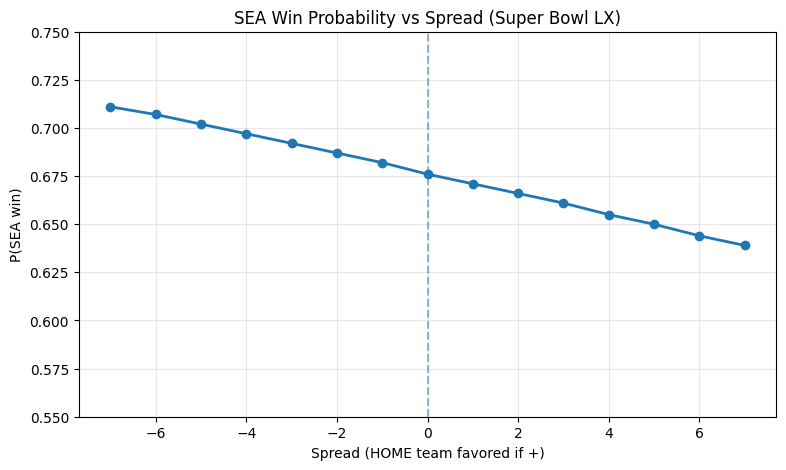

In [24]:
# ------------------------------------------------------------
# Final Chart: Win Probability vs Spread
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.plot(
    results_table["Spread (HOME)"],
    results_table[f"P({HOME_TEAM} win)"],
    marker="o",
    linewidth=2
)

plt.axhline(0.5, linestyle="--", alpha=0.5)
plt.axvline(0, linestyle="--", alpha=0.5)

plt.title(f"{HOME_TEAM} Win Probability vs Spread (Super Bowl LX)")
plt.xlabel("Spread (HOME team favored if +)")
plt.ylabel(f"P({HOME_TEAM} win)")
plt.ylim(0.55, 0.75)
plt.grid(alpha=0.3)

plt.show()
